In [30]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: c:\Users\PC_829\Documents\GitHub\HW2


# Tarea 3: SANITY CHECK 

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from source.data.sampling import create_time_series
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Simulacion


In [32]:
types_of_series = ['stationary', 'unit_root', 'break', 'outlier', 'nonlinear_trend']
nobs = 200
dataset = {}
for kind in types_of_series:
    dataset[kind] = create_time_series(kind, nobs, randseed=42) # para que todos los test se comparen con los mismos datos
dataset['t'] = np.linspace(0, 1, nobs)

✅ Figura guardada exitosamente en ./presentation/figures/hw3/simulations.pdf


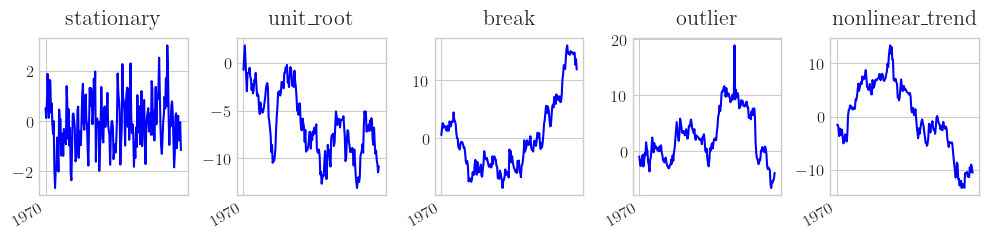

In [14]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(10, 2.5), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/simulations.pdf')

## Test 0: LJung Bx 

In [ ]:
resultados_ljung_box = testmodule.test_ljungbox(dataset['stationary'], lags=5)
resultados_ljung_box

Test Ljung-Box


,statistic,p-value
0,704.545724,5.109407e-150


## Test 1: DF (Dickey-Fuller)

In [7]:
metrics = testmodule.test_df(dataset['stationary'])

Test DF


## Test 2: ADF (Augmented Dickey-Fuller)

In [33]:
metrics = testmodule.test_adf(dataset['stationary'])

TypeError: test_adf() takes 0 positional arguments but 1 was given

## Test 3: PP (Phillips-Perron)

In [40]:
metrics = testmodule.test_pp(dataset['unit_root'])
print("=== Test de Phillips-Perron ===")
print(metrics.to_string(index=False))

=== Test de Phillips-Perron ===
                Metrica      Valor
 Estadistico Zrho Case1  -0.800492
     Valor P Zrho Case1   0.571052
     rho estimado Case1    0.99491
 Valor Critico 1% Case1      -11.8
 Valor Critico 5% Case1       -7.3
Valor Critico 10% Case1       -5.3
 Estadistico Zrho Case2  -9.621215
     Valor P Zrho Case2   0.058521
     rho estimado Case2   0.949553
 Valor Critico 1% Case2      -13.8
 Valor Critico 5% Case2       -8.1
Valor Critico 10% Case2       -5.7
 Estadistico Zrho Case4 -17.436409
     Valor P Zrho Case4   0.000782
   Estadistico Zt Case4  -3.012106
       Valor P Zt Case4   0.804929
     rho estimado Case4   0.914181
 Valor Critico 1% Case4      -20.7
 Valor Critico 5% Case4      -14.1
Valor Critico 10% Case4      -11.3
          Observaciones        199
            Rezagos (q)          4
      Tipo de regresion        all


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [ ]:
metrics = testmodule.test_kpss(dataset['stationary'])

Test KPSS


## Test 5: Perron

In [ ]:
metrics = testmodule.test_perron(dataset['stationary'])

Test Perron


## Test 6: Zivot-Andrews

In [ ]:
metrics = testmodule.test_zivot_andrews(dataset['stationary'])

Test Zivot-Andrews


## Test 7: Bierens

In [ ]:
metrics = testmodule.test_bierens(dataset['stationary'])

Test Bierens


## Test 8: Murray and Nelson

In [ ]:
metrics = testmodule.test_murray_nelson(dataset['stationary'])

Test Murray-Nelson


## Test 9: GLS detrending

In [ ]:
metrics = testmodule.test_gls(dataset['stationary'])

Test GLS
